In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import Required Libraries
import os
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    Flatten,
    BatchNormalization,
    GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score
)

In [ ]:
# Extract ASL Dataset
import zipfile

zip_path = "/content/drive/MyDrive/asl_alphabet_dataset.zip"

extract_path = "/content/asl_dataset"

# Create extraction folder
os.makedirs(extract_path, exist_ok=True)

# Extract ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


### Create Train, Validation, and Test Datasets

The extracted ASL dataset is divided into training, validation, and testing datasets. Each class contains 700 training images, 300 validation images, and 300 testing images to ensure balanced dataset distribution across all classes.

In [ ]:
# Create Train / Validation / Test Split

# Original dataset path
original_dataset = "/content/asl_dataset/asl_alphabet_dataset"

# New dataset path
base_dir = "/content/asl_alphabet_dataset_split"

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "validation")
test_dir = os.path.join(base_dir, "test")

# Create folders
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Split counts
TRAIN_COUNT = 700
VAL_COUNT = 300
TEST_COUNT = 300

# Class names
classes = sorted(os.listdir(original_dataset))

# Create split dataset
for class_name in classes:

    class_path = os.path.join(original_dataset, class_name)

    # Skip non-folder files
    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)

    # Shuffle images
    random.shuffle(images)

    # Split images
    train_images = images[:TRAIN_COUNT]
    val_images = images[TRAIN_COUNT:TRAIN_COUNT + VAL_COUNT]
    test_images = images[
        TRAIN_COUNT + VAL_COUNT:
        TRAIN_COUNT + VAL_COUNT + TEST_COUNT
    ]

    # Create class folders
    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

    # Copy train images
    for image in train_images:
        src = os.path.join(class_path, image)
        dst = os.path.join(train_dir, class_name, image)
        shutil.copy(src, dst)

    # Copy validation images
    for image in val_images:
        src = os.path.join(class_path, image)
        dst = os.path.join(val_dir, class_name, image)
        shutil.copy(src, dst)

    # Copy test images
    for image in test_images:
        src = os.path.join(class_path, image)
        dst = os.path.join(test_dir, class_name, image)
        shutil.copy(src, dst)

print("Dataset split completed successfully!")

Dataset split completed successfully!


In [ ]:
# Count Total Images

def count_images(folder_path):

    total_images = 0

    for class_name in os.listdir(folder_path):

        class_path = os.path.join(folder_path, class_name)

        if os.path.isdir(class_path):

            total_images += len(os.listdir(class_path))

    return total_images


# Count images
train_images = count_images(train_dir)
val_images = count_images(val_dir)
test_images = count_images(test_dir)



# Print results
print("Total Training Images:", train_images)
print("Total Validation Images:", val_images)
print("Total Testing Images:", test_images)
print("\nTotal Dataset Images:",
      train_images + val_images + test_images)

Total Training Images: 20300
Total Validation Images: 8700
Total Testing Images: 8700

Total Dataset Images: 37700


In [ ]:
# Remove hidden system files from class list

classes = sorted([
    folder for folder in os.listdir(train_dir)
    if not folder.startswith(".")
])

print(classes)
print("\nNumber of Classes:", len(classes))

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']

Number of Classes: 29


### Dataset Visualization and Analysis

This section visualizes the dataset distribution and sample ASL images from different classes. Dataset analysis helps verify class balance and understand the structure of the image dataset before training deep learning models.

In [ ]:
# Dataset Statistics

print("Training Images:", train_images)
print("Validation Images:", val_images)
print("Testing Images:", test_images)

print("\nNumber of Classes:", len(classes))

Training Images: 20300
Validation Images: 8700
Testing Images: 8700

Number of Classes: 29


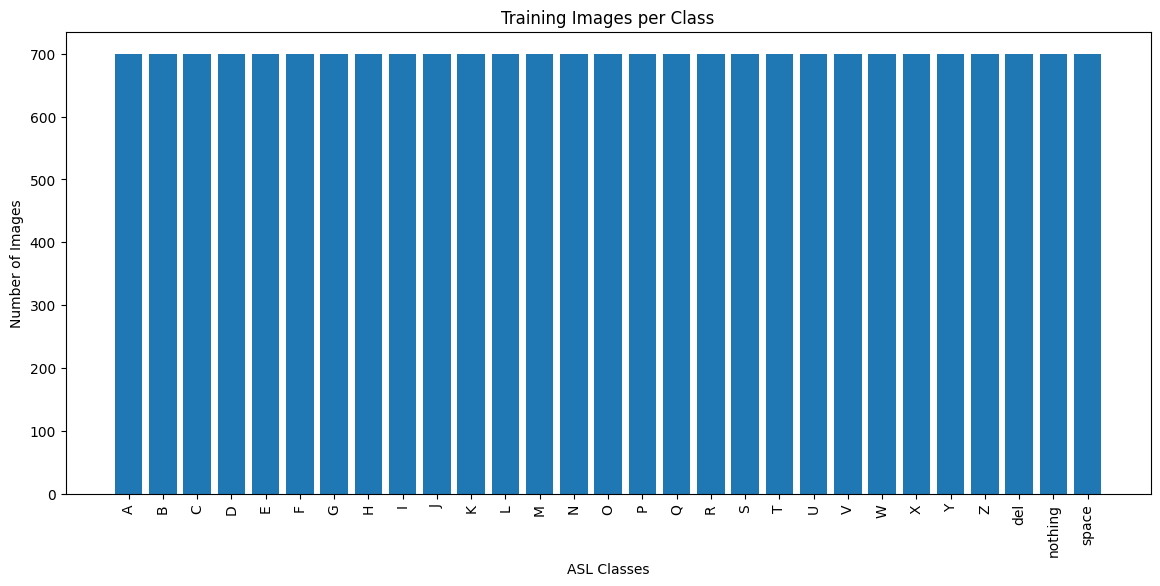

In [ ]:
# Visualize Class Distribution

class_counts = []
for class_name in classes:
    class_path = os.path.join(train_dir, class_name)
    count = len(os.listdir(class_path))
    class_counts.append(count)

# Plot
plt.figure(figsize=(14,6))
plt.bar(classes, class_counts)
plt.title("Training Images per Class")
plt.xlabel("ASL Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)
plt.show()

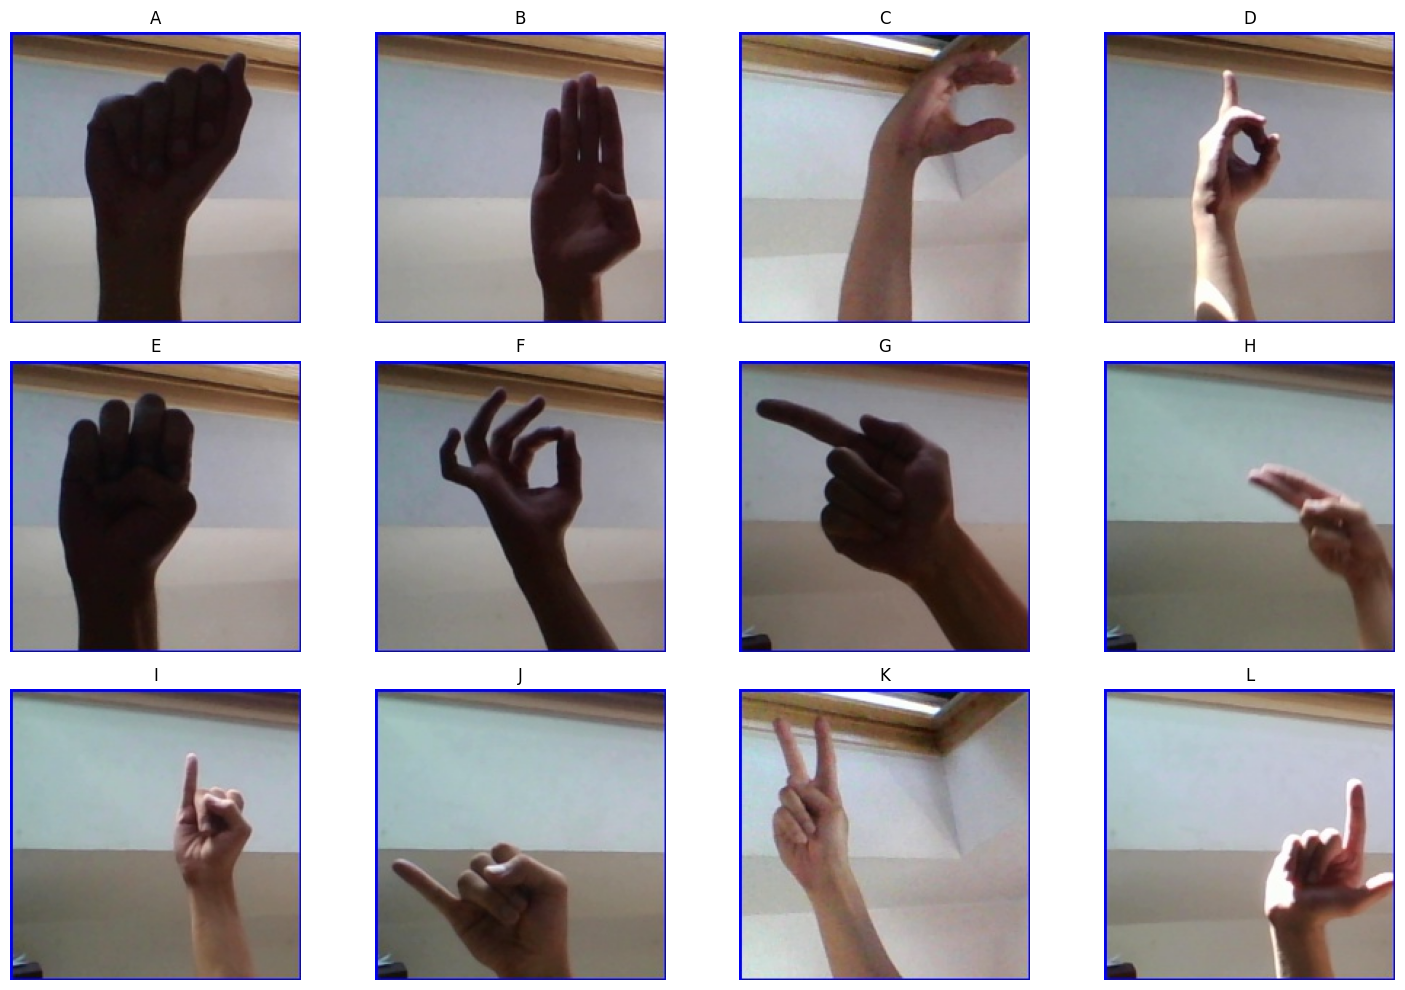

In [ ]:
# Display Sample Images

plt.figure(figsize=(15,10))

for i, class_name in enumerate(classes[:12]):
    class_path = os.path.join(train_dir, class_name)
    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)
    image = plt.imread(image_path)
    plt.subplot(3, 4, i+1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Check Image Shape

sample_class = classes[0]
sample_class_path = os.path.join(train_dir, sample_class)
sample_image = random.choice(os.listdir(sample_class_path))
sample_image_path = os.path.join(sample_class_path, sample_image)
image = plt.imread(sample_image_path)
print("Image Shape:", image.shape)

Image Shape: (200, 200, 3)


### Image Preprocessing and Data Generators

This section prepares the ASL image dataset for deep learning model training. Image preprocessing includes resizing, normalization, and data augmentation to improve model generalization performance.

ImageDataGenerator is used to efficiently load and preprocess images during training and evaluation.

In [ ]:
# Image Settings

IMG_HEIGHT = 128
IMG_WIDTH = 128

BATCH_SIZE = 32

In [ ]:
# Image Data Generators

# Training data generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False
)

# Validation and testing generators
test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
# Training Generator

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Validation Generator

validation_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Testing Generator

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 20284 images belonging to 29 classes.
Found 8692 images belonging to 29 classes.
Found 8695 images belonging to 29 classes.


## Baseline CNN Model

A baseline Convolutional Neural Network (CNN) model is developed to perform ASL alphabet image classification. This model serves as the initial deep learning architecture and provides a performance reference for later improved CNN and transfer learning models.

### Build Baseline CNN Architecture

In [ ]:
# Build Baseline CNN Model
baseline_model = Sequential()

# First Convolution Block
baseline_model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )
)

baseline_model.add(
    MaxPooling2D(pool_size=(2,2))
)

# Second Convolution Block
baseline_model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)
baseline_model.add(
    MaxPooling2D(pool_size=(2,2))
)

# Third Convolution Block
baseline_model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

baseline_model.add(
    MaxPooling2D(pool_size=(2,2))
)

# Flatten Layer
baseline_model.add(Flatten())

# Dense Layer
baseline_model.add(
    Dense(128, activation='relu')
)

# Dropout Layer
baseline_model.add(
    Dropout(0.5)
)

# Output Layer
baseline_model.add(
    Dense(29, activation='softmax')
)

# Model Summary
baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,308,381 (12.62 MB)

 Trainable params: 3,308,381 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile Baseline CNN Model

baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Callbacks for Baseline CNN

early_stopping_baseline = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

reduce_lr_baseline = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

### Train Baseline CNN Model

The baseline CNN model is trained using the augmented training dataset and validated using the validation dataset.

In [ ]:
# Train Baseline CNN Model

history_baseline = baseline_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15,
    callbacks=[
        early_stopping_baseline,
        reduce_lr_baseline
    ],
    verbose=1
)

Epoch 1/15
634/634 ━━━━━━━━━━━━━━━━━━━━ 125s 186ms/step - accuracy: 0.2887 - loss: 2.3746 - val_accuracy: 0.7378 - val_loss: 0.8876 - learning_rate: 0.0010
Epoch 2/15
634/634 ━━━━━━━━━━━━━━━━━━━━ 112s 177ms/step - accuracy: 0.6136 - loss: 1.1715 - val_accuracy: 0.8817 - val_loss: 0.4183 - learning_rate: 0.0010
Epoch 3/15
634/634 ━━━━━━━━━━━━━━━━━━━━ 111s 175ms/step - accuracy: 0.7248 - loss: 0.8021 - val_accuracy: 0.9276 - val_loss: 0.2585 - learning_rate: 0.0010
Epoch 4/15
634/634 ━━━━━━━━━━━━━━━━━━━━ 114s 181ms/step - accuracy: 0.7816 - loss: 0.6239 - val_accuracy: 0.9578 - val_loss: 0.1839 - learning_rate: 0.0010
Epoch 5/15
634/634 ━━━━━━━━━━━━━━━━━━━━ 111s 175ms/step - accuracy: 0.8226 - loss: 0.5082 - val_accuracy: 0.9561 - val_loss: 0.1436 - learning_rate: 0.0010
Epoch 6/15
634/634 ━━━━━━━━━━━━━━━━━━━━ 109s 173ms/step - accuracy: 0.8463 - loss: 0.4373 - val_accuracy: 0.9748 - val_loss: 0.0908 - learning_rate: 0.0010
Epoch 7/15
634/634 ━━━━━━━━━━━━━━━━━━━━ 109s 172ms/step - accura

### Evaluating Baseline CNN Model

The trained baseline CNN model is evaluated using the testing dataset to measure overall classification performance.

In [ ]:
# Evaluating Baseline CNN Model

test_loss_baseline, test_accuracy_baseline = baseline_model.evaluate(
    test_generator
)
print("Test Loss:", test_loss_baseline)
print("Test Accuracy:", test_accuracy_baseline)

272/272 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.9962 - loss: 0.0180
Test Loss: 0.018046915531158447
Test Accuracy: 0.9962047338485718


In [ ]:
# Generate Predictions

y_pred_prob_baseline = baseline_model.predict(test_generator)
y_pred_baseline = np.argmax(y_pred_prob_baseline, axis=1)
y_true_baseline = test_generator.classes

272/272 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step


In [ ]:
# Classification Report

class_labels = list(test_generator.class_indices.keys())
report_baseline = classification_report(
    y_true_baseline,
    y_pred_baseline,
    target_names=class_labels
)
print("Classification Report - Baseline CNN Model\n")
print(report_baseline)

Classification Report - Baseline CNN Model

              precision    recall  f1-score   support

           A       1.00      1.00      1.00       300
           B       1.00      1.00      1.00       300
           C       1.00      1.00      1.00       300
           D       1.00      1.00      1.00       300
           E       1.00      0.98      0.99       300
           F       1.00      1.00      1.00       299
           G       1.00      1.00      1.00       300
           H       1.00      1.00      1.00       300
           I       0.99      1.00      0.99       300
           J       1.00      1.00      1.00       300
           K       1.00      1.00      1.00       300
           L       1.00      1.00      1.00       300
           M       1.00      0.98      0.99       300
           N       0.98      1.00      0.99       300
           O       1.00      1.00      1.00       300
           P       1.00      1.00      1.00       299
           Q       1.00      1.00    

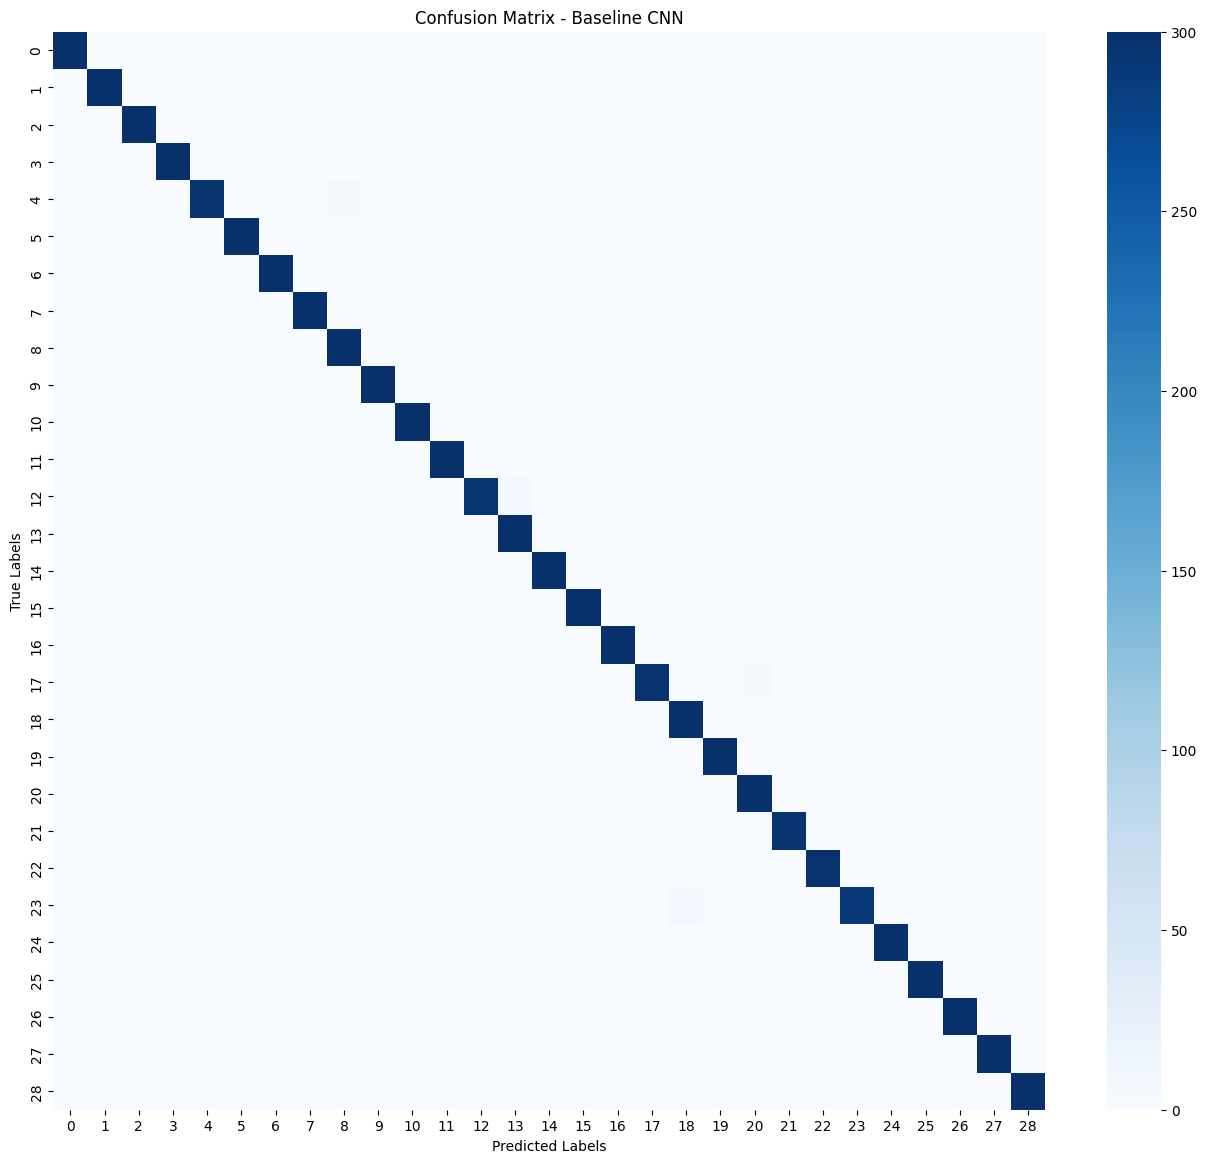

In [ ]:
# Confusion Matrix

cm_baseline = confusion_matrix(
    y_true_baseline,
    y_pred_baseline
)

# Plot confusion matrix
plt.figure(figsize=(16,14))

sns.heatmap(
    cm_baseline,
    cmap='Blues',
    annot=False
)

plt.title("Confusion Matrix - Baseline CNN")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

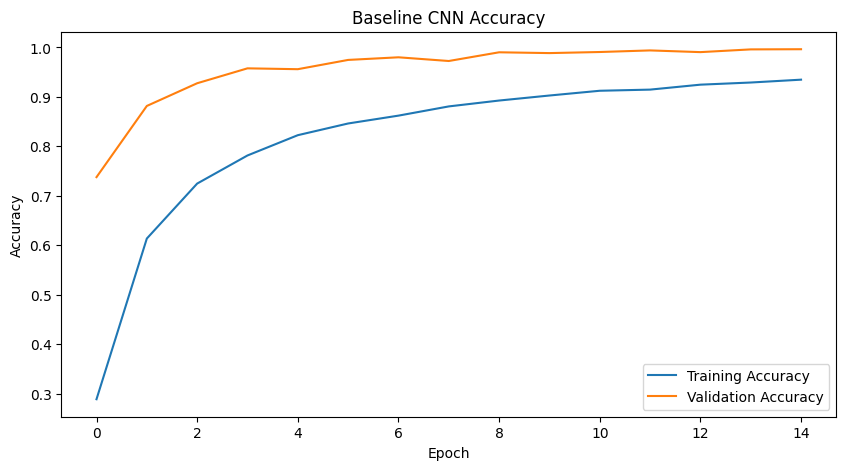

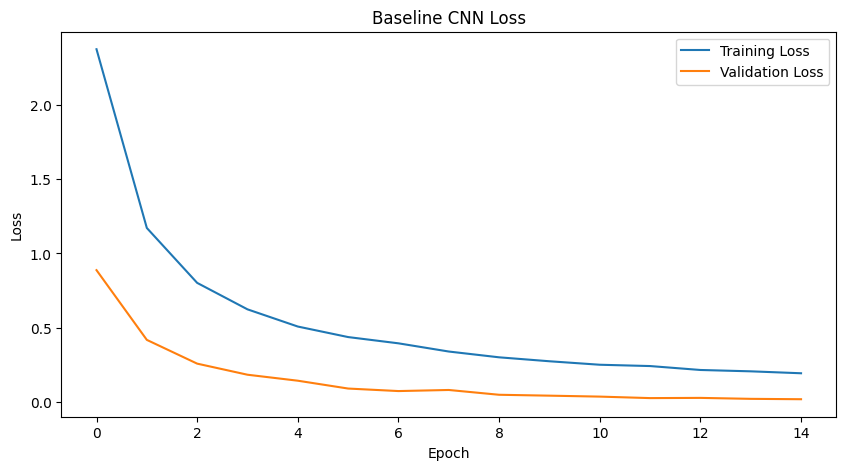

In [ ]:
# Plot Training Curves

# Accuracy Plot
plt.figure(figsize=(10,5))

plt.plot(
    history_baseline.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_baseline.history['val_accuracy'],
    label='Validation Accuracy'
)
plt.title("Baseline CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss Plot
plt.figure(figsize=(10,5))

plt.plot(
    history_baseline.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_baseline.history['val_loss'],
    label='Validation Loss'
)
plt.title("Baseline CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

#### Observation from Training Curves

The baseline CNN model showed stable learning performance throughout the training process. Training accuracy increased steadily while training and validation loss decreased consistently across the epochs.

The model achieved strong validation accuracy with minimal overfitting, indicating effective feature learning and good generalization performance on the ASL image dataset.

## Improved CNN Model

An improved CNN architecture is developed to enhance feature extraction, training stability, and generalization performance. Batch normalization and deeper convolutional layers are added to improve classification performance on the ASL image dataset.

### Build Improved CNN Architecture

Using additional convolutional layers, batch normalization, and dropout regularization to improve learning performance in the model.

In [ ]:
# Build Improved CNN Model

improved_model = Sequential()

# First Convolution Block
improved_model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )
)

improved_model.add(BatchNormalization())

improved_model.add(
    MaxPooling2D(pool_size=(2,2))
)

# Second Convolution Block
improved_model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

improved_model.add(BatchNormalization())

improved_model.add(
    MaxPooling2D(pool_size=(2,2))
)

# Third Convolution Block
improved_model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

improved_model.add(BatchNormalization())

improved_model.add(
    MaxPooling2D(pool_size=(2,2))
)

# Fourth Convolution Block
improved_model.add(
    Conv2D(
        256,
        (3,3),
        activation='relu'
    )
)

improved_model.add(BatchNormalization())

improved_model.add(
    MaxPooling2D(pool_size=(2,2))
)

# Flatten Layer
improved_model.add(Flatten())

# Dense Layer
improved_model.add(
    Dense(256, activation='relu')
)

# Dropout Layer
improved_model.add(
    Dropout(0.5)
)

# Output Layer
improved_model.add(
    Dense(29, activation='softmax')
)

# Model Summary
improved_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,757,341 (10.52 MB)

 Trainable params: 2,756,381 (10.51 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# Compile Improved CNN Model

improved_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Callbacks for Improved CNN

early_stopping_improved = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

reduce_lr_improved = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

In [ ]:
# Train Improved CNN Model

history_improved = improved_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15,
    callbacks=[
        early_stopping_improved,
        reduce_lr_improved
    ],
    verbose=1
)

Epoch 1/15
634/634 ━━━━━━━━━━━━━━━━━━━━ 133s 196ms/step - accuracy: 0.2593 - loss: 2.4515 - val_accuracy: 0.5843 - val_loss: 1.2585 - learning_rate: 0.0010
Epoch 2/15
634/634 ━━━━━━━━━━━━━━━━━━━━ 124s 196ms/step - accuracy: 0.4613 - loss: 1.5723 - val_accuracy: 0.2017 - val_loss: 6.4892 - learning_rate: 0.0010
Epoch 3/15
634/634 ━━━━━━━━━━━━━━━━━━━━ 119s 188ms/step - accuracy: 0.6316 - loss: 1.0631 - val_accuracy: 0.7745 - val_loss: 0.6420 - learning_rate: 0.0010
Epoch 4/15
634/634 ━━━━━━━━━━━━━━━━━━━━ 124s 196ms/step - accuracy: 0.7439 - loss: 0.7348 - val_accuracy: 0.6536 - val_loss: 1.2149 - learning_rate: 0.0010
Epoch 5/15
634/634 ━━━━━━━━━━━━━━━━━━━━ 119s 188ms/step - accuracy: 0.8170 - loss: 0.5190 - val_accuracy: 0.8621 - val_loss: 0.3879 - learning_rate: 0.0010
Epoch 6/15
634/634 ━━━━━━━━━━━━━━━━━━━━ 116s 183ms/step - accuracy: 0.8611 - loss: 0.4049 - val_accuracy: 0.8546 - val_loss: 0.7084 - learning_rate: 0.0010
Epoch 7/15
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy

### Evaluate Improved CNN Model

The trained improved CNN model is evaluated using the testing dataset to measure overall classification performance.

In [ ]:
# Evaluate Improved CNN Model

test_loss_improved, test_accuracy_improved = improved_model.evaluate(
    test_generator
)
print("Test Loss:", test_loss_improved)
print("Test Accuracy:", test_accuracy_improved)

272/272 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.8585 - loss: 0.3999
Test Loss: 0.3999219536781311
Test Accuracy: 0.8585394024848938


In [ ]:
# Generate Predictions

y_pred_prob_improved = improved_model.predict(test_generator)
y_pred_improved = np.argmax(y_pred_prob_improved, axis=1)
y_true_improved = test_generator.classes

272/272 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step


In [ ]:
# Classification Report

class_labels = list(test_generator.class_indices.keys())
report_improved = classification_report(
    y_true_improved,
    y_pred_improved,
    target_names=class_labels
)
print("Classification Report - Improved CNN Model\n")
print(report_improved)

Classification Report - Improved CNN Model

              precision    recall  f1-score   support

           A       0.85      0.86      0.86       300
           B       0.97      0.96      0.96       300
           C       1.00      0.99      0.99       300
           D       0.98      1.00      0.99       300
           E       0.81      0.81      0.81       300
           F       0.99      1.00      0.99       299
           G       0.84      1.00      0.91       300
           H       1.00      0.79      0.88       300
           I       0.99      0.79      0.88       300
           J       0.96      0.98      0.97       300
           K       1.00      0.92      0.96       300
           L       0.93      1.00      0.96       300
           M       0.86      0.80      0.83       300
           N       0.99      0.84      0.91       300
           O       0.84      0.94      0.89       300
           P       0.98      0.79      0.87       299
           Q       0.63      1.00    

### Confusion Matrix

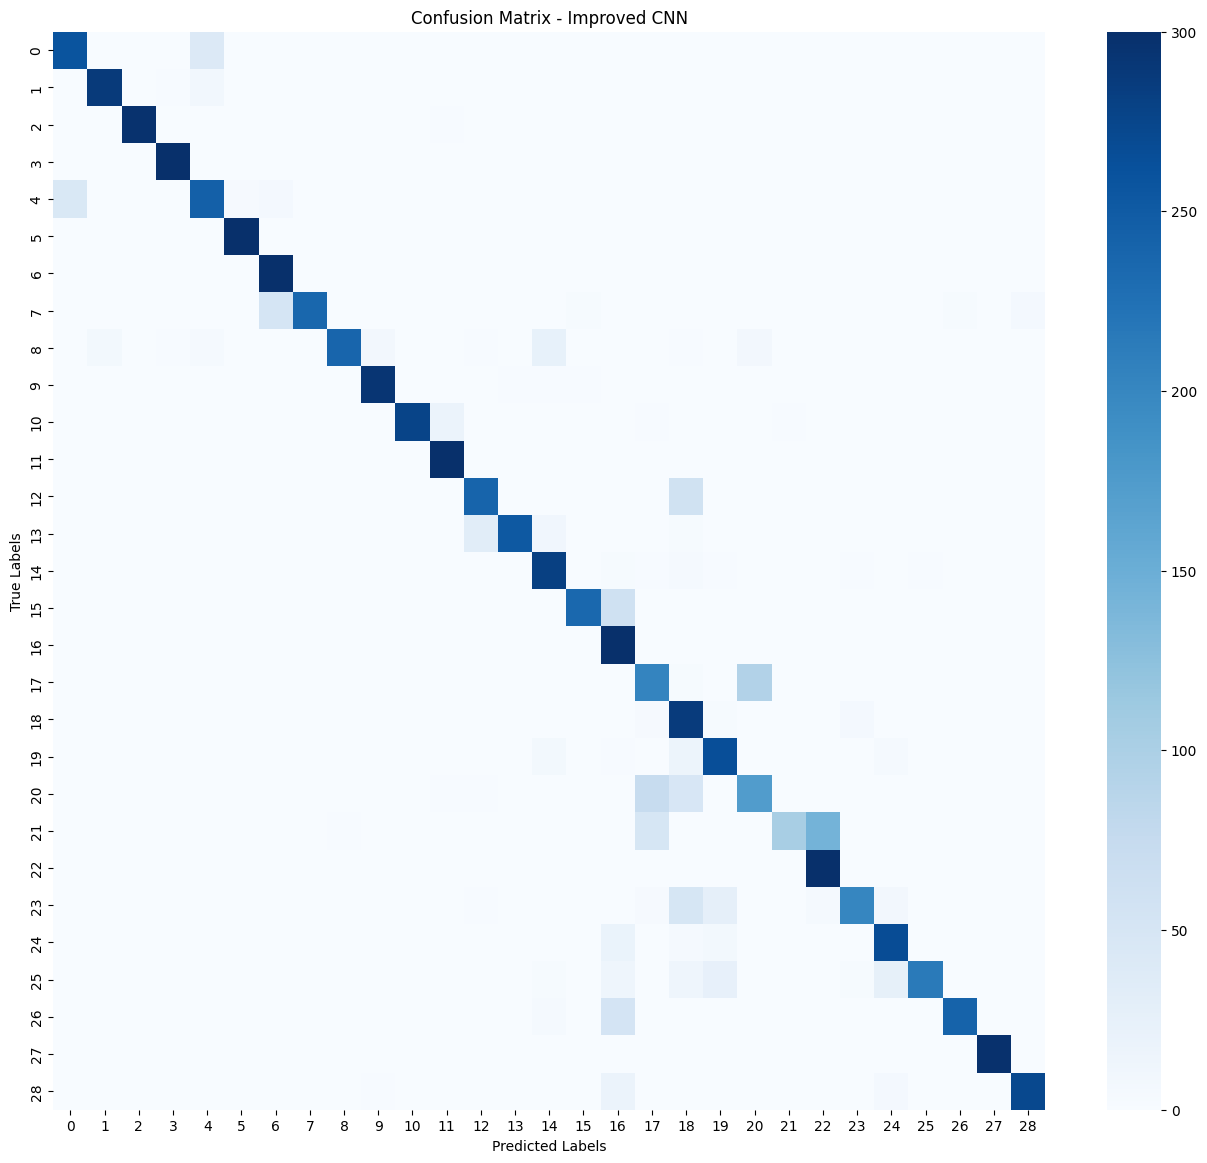

In [ ]:
# Confusion Matrix

cm_improved = confusion_matrix(
    y_true_improved,
    y_pred_improved
)

# Plot confusion matrix
plt.figure(figsize=(16,14))

sns.heatmap(
    cm_improved,
    cmap='Blues',
    annot=False
)
plt.title("Confusion Matrix - Improved CNN")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

#### Observation from Confusion Matrix

### Training Curves

Training and validation accuracy and loss curves are visualized to analyze the learning performance of the improved CNN model during training.

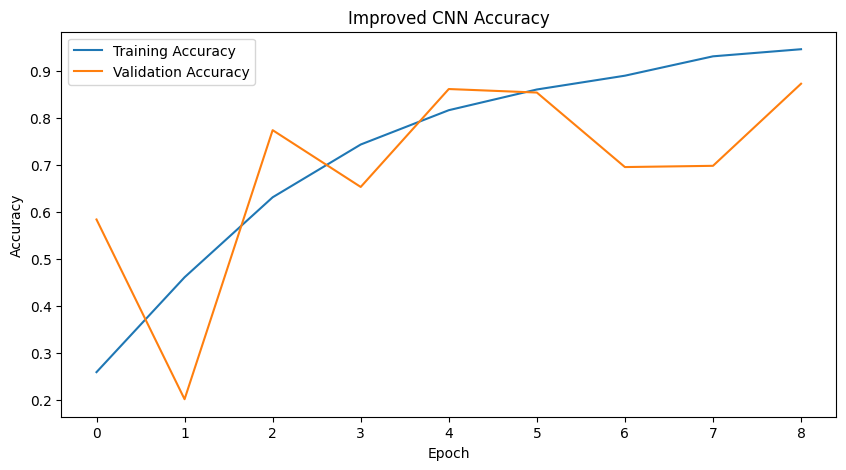

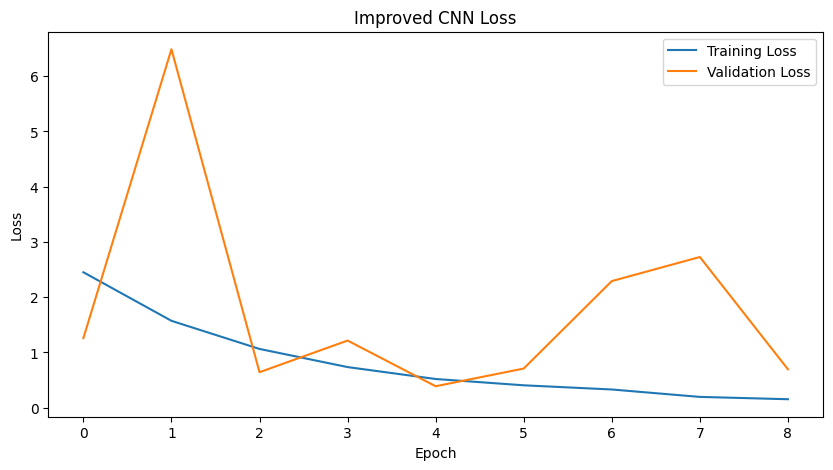

In [ ]:
# Plot Training Curves

# Accuracy Plot
plt.figure(figsize=(10,5))

plt.plot(
    history_improved.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_improved.history['val_accuracy'],
    label='Validation Accuracy'
)
plt.title("Improved CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss Plot
plt.figure(figsize=(10,5))

plt.plot(
    history_improved.history['loss'],
    label='Training Loss'
)
plt.plot(
    history_improved.history['val_loss'],
    label='Validation Loss'
)
plt.title("Improved CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

#### Observation from Training Curves

## Transfer Learning using MobileNetV2

Transfer learning using MobileNetV2 is implemented to improve feature extraction and classification performance on the ASL image dataset. MobileNetV2 is a lightweight pretrained deep learning architecture that uses knowledge learned from large-scale image datasets to improve image classification efficiency and generalization.

### Create MobileNetV2 Data & Dataset Generators

as MobileNetV2 is a specific preprocessing function to normalize image pixel values before training and evaluation where as Dataset generators load and preprocess images for MobileNetV2 training and evaluation.

In [ ]:
# MobileNetV2 Data Generators

mobilenet_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False
)
mobilenet_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [ ]:
# MobileNetV2 Dataset Generators

mobilenet_train_generator = mobilenet_train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

mobilenet_validation_generator = mobilenet_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

mobilenet_test_generator = mobilenet_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 20284 images belonging to 29 classes.
Found 8692 images belonging to 29 classes.
Found 8695 images belonging to 29 classes.


### Building MobileNetV2 Transfer Learning Model

The pretrained MobileNetV2 model is used as the base feature extractor, while additional custom classification layers are added for ASL alphabet classification.

In [ ]:
# Load MobileNetV2 Base Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

base_model.trainable = False

In [ ]:
# Build Transfer Learning Model
mobilenet_model = Sequential()

# Add pretrained base model
mobilenet_model.add(base_model)

# Global Average Pooling
mobilenet_model.add(GlobalAveragePooling2D())

# Dense Layer
mobilenet_model.add(
    Dense(128, activation='relu')
)

# Dropout Layer
mobilenet_model.add(
    Dropout(0.5)
)

# Output Layer
mobilenet_model.add(
    Dense(29, activation='softmax')
)

# Model Summary
mobilenet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,425,693 (9.25 MB)

 Trainable params: 167,709 (655.11 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Compile MobileNetV2 Model

The MobileNetV2 transfer learning model is compiled using the Adam optimizer and categorical cross-entropy loss function for multi-class ASL image classification.

In [ ]:
# Compile MobileNetV2 Model

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Callbacks for MobileNetV2

early_stopping_mobilenet = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

reduce_lr_mobilenet = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

In [ ]:
# Train MobileNetV2 Model

history_mobilenet = mobilenet_model.fit(
    mobilenet_train_generator,
    validation_data=mobilenet_validation_generator,
    epochs=15,
    callbacks=[
        early_stopping_mobilenet,
        reduce_lr_mobilenet
    ],
    verbose=1
)

Epoch 1/15
634/634 ━━━━━━━━━━━━━━━━━━━━ 172s 239ms/step - accuracy: 0.6928 - loss: 1.0437 - val_accuracy: 0.9681 - val_loss: 0.1511 - learning_rate: 0.0010
Epoch 2/15
634/634 ━━━━━━━━━━━━━━━━━━━━ 115s 181ms/step - accuracy: 0.8893 - loss: 0.3541 - val_accuracy: 0.9812 - val_loss: 0.0737 - learning_rate: 0.0010
Epoch 3/15
634/634 ━━━━━━━━━━━━━━━━━━━━ 115s 181ms/step - accuracy: 0.9138 - loss: 0.2673 - val_accuracy: 0.9846 - val_loss: 0.0548 - learning_rate: 0.0010
Epoch 4/15
634/634 ━━━━━━━━━━━━━━━━━━━━ 113s 178ms/step - accuracy: 0.9281 - loss: 0.2213 - val_accuracy: 0.9872 - val_loss: 0.0453 - learning_rate: 0.0010
Epoch 5/15
634/634 ━━━━━━━━━━━━━━━━━━━━ 111s 176ms/step - accuracy: 0.9331 - loss: 0.1989 - val_accuracy: 0.9888 - val_loss: 0.0341 - learning_rate: 0.0010
Epoch 6/15
634/634 ━━━━━━━━━━━━━━━━━━━━ 111s 175ms/step - accuracy: 0.9392 - loss: 0.1871 - val_accuracy: 0.9918 - val_loss: 0.0271 - learning_rate: 0.0010
Epoch 7/15
634/634 ━━━━━━━━━━━━━━━━━━━━ 111s 176ms/step - accura

### Evaluating MobileNetV2 Model

The trained MobileNetV2 transfer learning model is evaluated using the testing dataset to measure classification performance.

In [ ]:
# Evaluate MobileNetV2 Model

test_loss_mobilenet, test_accuracy_mobilenet = mobilenet_model.evaluate(
    mobilenet_test_generator
)
print("Test Loss:", test_loss_mobilenet)
print("Test Accuracy:", test_accuracy_mobilenet)

272/272 ━━━━━━━━━━━━━━━━━━━━ 22s 81ms/step - accuracy: 0.9948 - loss: 0.0193
Test Loss: 0.01932545192539692
Test Accuracy: 0.9948245882987976


In [ ]:
# Generating Predictions

y_pred_prob_mobilenet = mobilenet_model.predict(
    mobilenet_test_generator
)
y_pred_mobilenet = np.argmax(
    y_pred_prob_mobilenet,
    axis=1
)
y_true_mobilenet = mobilenet_test_generator.classes

272/272 ━━━━━━━━━━━━━━━━━━━━ 26s 78ms/step


### Classification Report

In [ ]:
# Classification Report

class_labels = list(
    mobilenet_test_generator.class_indices.keys()
)
report_mobilenet = classification_report(
    y_true_mobilenet,
    y_pred_mobilenet,
    target_names=class_labels
)
print("Classification Report - MobileNetV2 Model\n")
print(report_mobilenet)

Classification Report - MobileNetV2 Model

              precision    recall  f1-score   support

           A       1.00      1.00      1.00       300
           B       1.00      1.00      1.00       300
           C       1.00      1.00      1.00       300
           D       1.00      1.00      1.00       300
           E       1.00      0.99      0.99       300
           F       1.00      1.00      1.00       299
           G       0.99      1.00      0.99       300
           H       1.00      0.99      0.99       300
           I       0.99      1.00      0.99       300
           J       1.00      1.00      1.00       300
           K       1.00      0.99      0.99       300
           L       1.00      1.00      1.00       300
           M       1.00      1.00      1.00       300
           N       1.00      1.00      1.00       300
           O       1.00      0.99      0.99       300
           P       1.00      1.00      1.00       299
           Q       1.00      1.00     

#### Observation from Classification Report

The MobileNetV2 transfer learning model achieved excellent classification performance across most ASL classes with very high precision, recall, and F1-scores.

Compared to the previous CNN models, MobileNetV2 demonstrated more stable learning behavior and stronger generalization performance on the ASL image dataset.

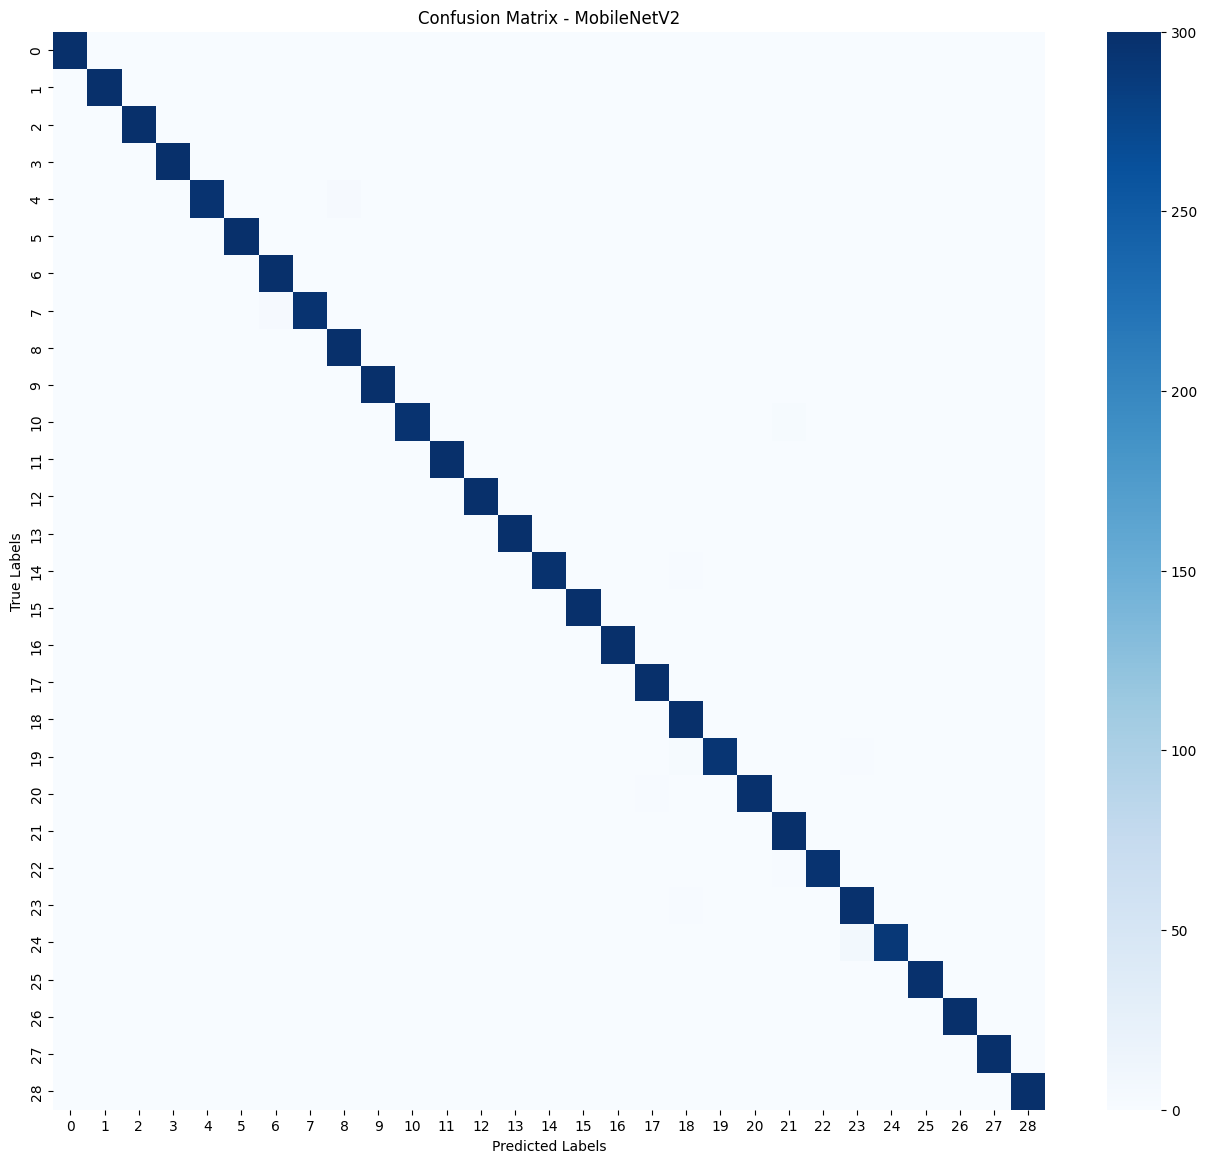

In [ ]:
# Confusion Matrix

cm_mobilenet = confusion_matrix(
    y_true_mobilenet,
    y_pred_mobilenet
)
# Plot confusion matrix
plt.figure(figsize=(16,14))
sns.heatmap(
    cm_mobilenet,
    cmap='Blues',
    annot=False
)
plt.title("Confusion Matrix - MobileNetV2")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

### Training Curves

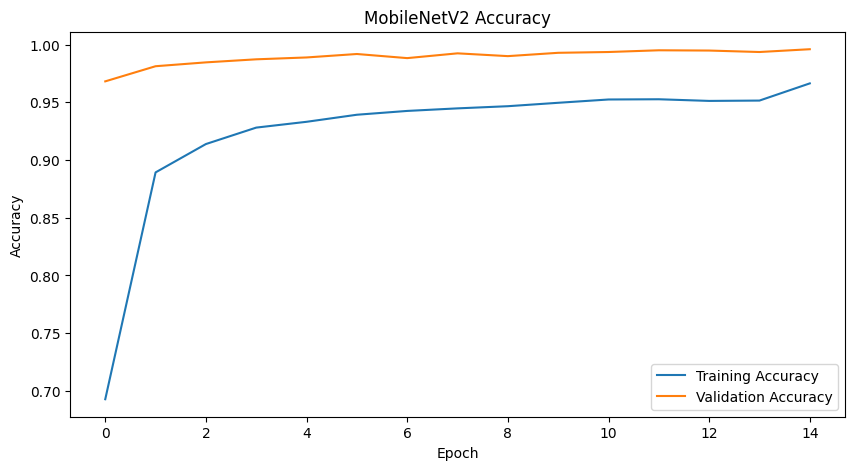

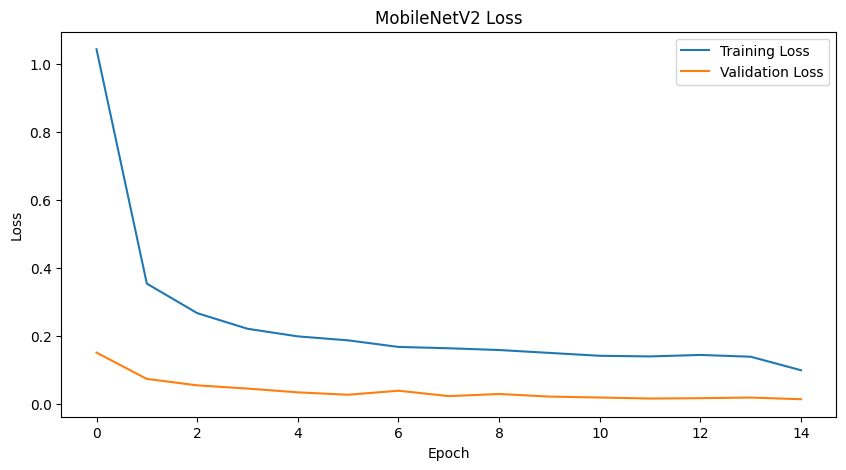

In [ ]:
# Plot Training Curves

# Accuracy Plot
plt.figure(figsize=(10,5))

plt.plot(
    history_mobilenet.history['accuracy'],
    label='Training Accuracy'
)
plt.plot(
    history_mobilenet.history['val_accuracy'],
    label='Validation Accuracy'
)
plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss Plot
plt.figure(figsize=(10,5))

plt.plot(
    history_mobilenet.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_mobilenet.history['val_loss'],
    label='Validation Loss'
)
plt.title("MobileNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

#### Observation from Training Curves

The MobileNetV2 transfer learning model achieved consistent learning results throughout its entire training period. The study showed that validation accuracy progressed through the entire testing period while validation loss experienced a continuous reduction.

## External Image Prediction Test

### Loading and preprocessing the external image

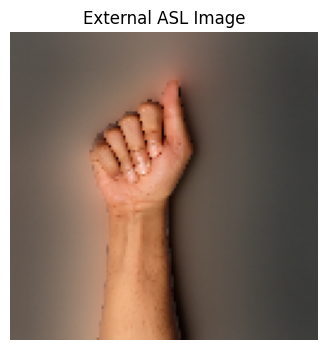

In [ ]:
# Load External Image

from tensorflow.keras.utils import load_img, img_to_array

# External image path
image_path = "/content/A.PNG"

# Load image
external_image = load_img(
    image_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH)
)

# Display image
plt.figure(figsize=(4,4))
plt.imshow(external_image)
plt.title("External ASL Image")
plt.axis("off")
plt.show()

In [ ]:
# Preprocess External Image

# Convert image to array
image_array = img_to_array(external_image)

# Expand dimensions
image_array = np.expand_dims(image_array, axis=0)

# Apply MobileNetV2 preprocessing
image_array = preprocess_input(image_array)

print("Processed Image Shape:", image_array.shape)

Processed Image Shape: (1, 128, 128, 3)


In [ ]:
# Predicting External Image

# Predict probabilities
prediction = mobilenet_model.predict(image_array)

# Get predicted class index
predicted_index = np.argmax(prediction)

# Get class labels
class_labels = list(
    mobilenet_train_generator.class_indices.keys()
)
# Get predicted label
predicted_label = class_labels[predicted_index]

# Get confidence score
confidence = np.max(prediction)
print("Predicted Label:", predicted_label)
print("Confidence Score:", round(confidence * 100, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Predicted Label: N
Confidence Score: 82.66 %


In [ ]:
# Count total images inside folder

folder_path = "/content/ASL_Test"

total_images = len(os.listdir(folder_path))

print("Total Images:", total_images)

Total Images: 0
